In [1]:
import os
import sys
import numpy as np
import pinocchio as pin
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

sys.path.append('./python/bsqp')
sys.path.append('./python')

from bsqp.mpc_controller_m2 import MPCState
from bsqp.mpc_controller_m2 import MPC_GATO
from bsqp.common import figure8
from bsqp.config import (
    EXPERIMENT_BATCH_SIZES,
    FIG8_DEFAULT_PARAMS, 
    FLEXIV_RIZON_4S_START_CONFIGS,
    BATCH_COLORS
)

np.random.seed(42)

print("Imports complete")

Imports complete


In [2]:
config = {
    'batch_sizes': [1],
    'N': 32,
    'dt': 0.01,
    'sim_time': 16.0,              # Total sim time
    'sim_dt': 0.001,               # Simulation timestep
    'start_config': 'home',        # Starting configuration ('zero', 'home', or 'ready')
    'f_ext': np.array([0.0, 0.0, -60.0, 0.0, 0.0, 0.0])  # External force [fx, fy, fz, mx, my, mz]
}

print("Configuration:")
print(f"  Batch sizes: {config['batch_sizes']}")
print(f"  Horizon: N={config['N']}, dt={config['dt']}s")
print(f"  Simulation: {config['sim_time']}s at {1/config['sim_dt']:.0f}Hz")
print(f"  External force: {config['f_ext'][:3]} N")

Configuration:
  Batch sizes: [1]
  Horizon: N=32, dt=0.01s
  Simulation: 16.0s at 1000Hz
  External force: [  0.   0. -60.] N


In [3]:
# Load robot model
urdf_path = "flexiv_description/flexiv_rizon4s_kinematics_vz.urdf"
model_dir = "flexiv_description/"

model, visual_model, collision_model = pin.buildModelsFromUrdf(urdf_path, model_dir)

print(f"  Loaded model")
print(f"  Joints: {model.njoints-1}")
print(f"  DOF: {model.nq}")
print(f"  Generalized velocity: {model.nv}")

  Loaded model
  Joints: 7
  DOF: 7
  Generalized velocity: 7


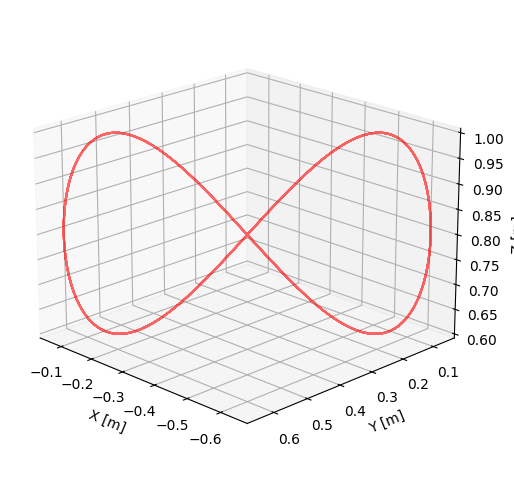

  Total points: 3000
  Duration: 30.0s


In [4]:
# Reference EE trajectory
fig8_traj = figure8(config['dt'], **FIG8_DEFAULT_PARAMS)

# Visualize
ref_points = fig8_traj.reshape(-1, 6)[:, :3]  # position components
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(ref_points[:, 0], ref_points[:, 1], ref_points[:, 2], 'r-', alpha=0.6)
ax.set_xlabel('X [m]')
ax.set_ylabel('Y [m]')
ax.set_zlabel('Z [m]')
ax.view_init(elev=20, azim=135)
plt.show()

print(f"  Total points: {len(ref_points)}")
print(f"  Duration: {len(ref_points) * config['dt']:.1f}s")

In [5]:
results = {}

# starting configuration
x_start = np.hstack((FLEXIV_RIZON_4S_START_CONFIGS[config['start_config']], np.zeros(model.nv)))

print("Running experiments...\n")
print("=" * 60)

for batch_size in config['batch_sizes']:
    print(f"\nBatch size {batch_size}:")
    print("-" * 40)
    
    # Create controller
    mpc = MPC_GATO(
        model=model,
        model_path=urdf_path,
        N=config['N'],
        dt=config['dt'],
        batch_size=batch_size,
        plant_type='flexiv_rizon4s',
        constant_f_ext=config['f_ext'],
        track_full_stats=True
    )
    _, stats, x_curr, ee_g = mpc.init_mpc(
        x_start,
        fig8_traj,
        problem_type="figure8"
    )

    ws_XU_best, ws_XU_batch, ee_g_batch = mpc.warm_start_mpc(
        x_curr,
        ee_g
    )

    mpc_flag = True

    mpc_state = MPCState(x_curr=x_curr,
                         x_last=np.zeros_like(x_curr),
                         u_last=np.zeros_like(ws_XU_best[mpc.nx:mpc.nx + mpc.nu]),
                         XU_batch=ws_XU_batch,
                         XU_best=ws_XU_best,
                         ee_g=ee_g,
                         ee_g_batch=ee_g_batch,
                         total_sim_time=0.0,
                         current_goal_idx=0,
                         goal_start_time=0.0
                         )
    while mpc_flag == True and mpc_state.total_sim_time < config['sim_time']:
        
        # Run MPC for the current goal
        mpc_flag = mpc.srun_mpc_figure8(
            state=mpc_state,
            goals=fig8_traj,
            sim_dt=config['sim_dt'],
            sim_time=config['sim_time'],
            stats=stats
        )

        if mpc_flag == False:
            break
    # Convert to numpy arrays
    for key in stats:
        if stats[key]:
            try:
                stats[key] = np.array(stats[key])
            except (ValueError, TypeError):
                # Keep as list if conversion fails
                pass
            
    # Print summary
    print(f"Avg error: {np.mean(stats['goal_distances']):.4f}m")
    print(f"Avg solve time: {np.mean(stats['solve_times']):.3f}ms")
    
    results[batch_size] = stats
    print(f"Completed {len(stats['timestamps'])} iterations")

print("\n" + "=" * 60)
print("All experiments complete")

Running experiments...


Batch size 1:
----------------------------------------
Starting joint positions: [0.0000, -0.6980, 0.0000, 1.5710, -0.0000, 0.6980, -0.0000]rad
Starting EE position: [0.3179, -0.3866, 0.5339]m
Avg error: 1.0154m
Avg solve time: 1.547ms
Completed 1601 iterations

All experiments complete


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


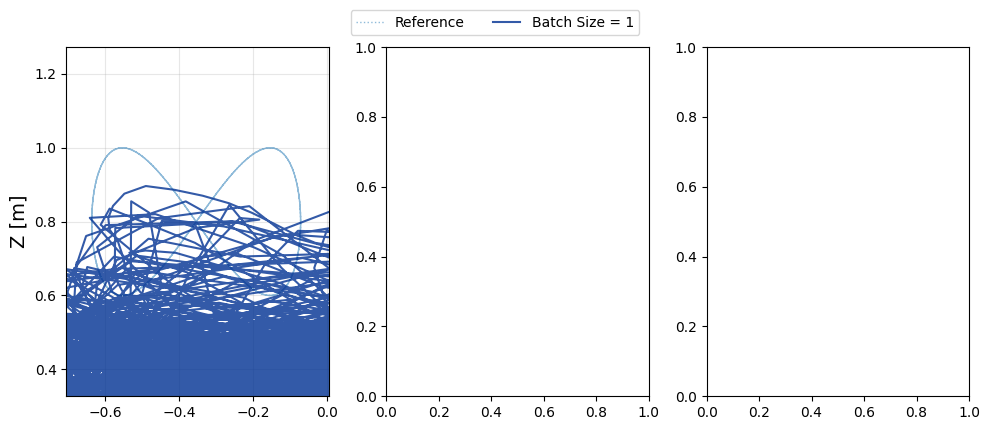

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
batch_sizes = sorted(results.keys())

for idx, batch_size in enumerate(batch_sizes):
    ax = axes[idx]
    
    # Plot reference traj (dotted line)
    ax.plot(ref_points[:, 0], ref_points[:, 2], ':', 
            linewidth=1.0, alpha=0.5, label='Reference')
    
    # Plot actual trajectory
    ee_actual = results[batch_size]['ee_actual']
    color = BATCH_COLORS.get(batch_size, '#000000')
    ax.plot(ee_actual[:, 0], ee_actual[:, 2],
            color=color, linewidth=1.5, label=f'Batch Size = {batch_size}', alpha=0.8)
    
    if idx == 0:
        ax.set_ylabel('Z [m]', fontsize=14)
    else:
        ax.tick_params(axis='y', which='both', left=False, labelleft=False)
    
    if idx == 1:
        ax.set_xlabel('X [m]', fontsize=14)
    
    ax.grid(True, alpha=0.3)
    ax.axis('equal')
    ax.set_xlim(-0.7, 0.0)
    ax.set_ylim(0.5, 1.1)

# Add single legend for all subplots
handles, labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# Remove duplicates
unique_labels = []
unique_handles = []
for handle, label in zip(handles, labels):
    if label not in unique_labels:
        unique_labels.append(label)
        unique_handles.append(handle)

fig.legend(unique_handles, unique_labels, loc='upper center', 
           bbox_to_anchor=(0.5, 1.08), ncol=4)

plt.tight_layout()
plt.subplots_adjust(top=0.97)
plt.show()